In [1]:
!pip install -q git+https://github.com/amazon-science/chronos-forecasting.git
!pip install -q datasets gluonts transformers accelerate scikit-learn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import sys
sys.path.insert(0, "/content/chronos-forecasting/src")
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from chronos import ChronosConfig, ChronosPipeline
from transformers import AutoModelForSeq2SeqLM, Trainer, TrainingArguments
from torch.utils.data import IterableDataset
from datasets import load_dataset
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

dataset = load_dataset("autogluon/chronos_datasets", "m4_hourly", split="train")
df = dataset.to_pandas()
print(f"   Загружено {len(df)} записей")
print(f"   Всего рядов: {len(df['id'].unique())}")

Using device: cuda


README.md:   0%|          | 0.00/44.3k [00:00<?, ?B/s]

m4_hourly/train-00000-of-00001.parquet:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/414 [00:00<?, ? examples/s]

   Загружено 414 записей
   Всего рядов: 414


In [5]:
all_series_ids = df['id'].unique()
print(f"   Всего рядов: {len(all_series_ids)}")

   Всего рядов: 414


In [6]:
CONTEXT_LENGTH = 128
PREDICTION_LENGTH = 24
MAX_STEPS = 500
BATCH_SIZE = 8

all_series = []
for series_id in all_series_ids:
    series = df[df['id'] == series_id]['target'].values[0]
    if isinstance(series, np.ndarray):
        series = series.tolist()
    if len(series) > CONTEXT_LENGTH + PREDICTION_LENGTH + 10:
        series = series[:CONTEXT_LENGTH + PREDICTION_LENGTH]
        all_series.append(series)

print(f"   Подготовлено рядов: {len(all_series)}")

   Подготовлено рядов: 414


In [7]:
train_series, test_series = train_test_split(
    all_series,
    test_size=0.2,
    random_state=42
)

print(f"   Обучающих рядов: {len(train_series)}")
print(f"   Тестовых рядов: {len(test_series)}")

   Обучающих рядов: 331
   Тестовых рядов: 83


In [8]:
def prepare_data(series_list, context_len, pred_len):
    data = []
    for series in series_list:
        if len(series) < context_len + pred_len:
            continue
        for i in range(len(series) - context_len - pred_len + 1):
            context = series[i:i+context_len]
            future = series[i+context_len:i+context_len+pred_len]
            if len(context) == context_len and len(future) == pred_len:
                data.append({
                    "context": context,
                    "future": future,
                })
    return data

train_data = prepare_data(train_series, CONTEXT_LENGTH, PREDICTION_LENGTH)
print(f"   Создано {len(train_data)} примеров")

   Создано 331 примеров


In [9]:
class ChronosDataset(IterableDataset):
    def __init__(self, data, tokenizer, config):
        self.data = data
        self.tokenizer = tokenizer
        self.vocab_size = config.n_tokens + config.n_special_tokens
        self.indices = list(range(len(data)))

    def __iter__(self):
        np.random.shuffle(self.indices)
        for idx in self.indices:
            item = self.data[idx]
            context = torch.tensor(item["context"], dtype=torch.float32).unsqueeze(0)
            future = torch.tensor(item["future"], dtype=torch.float32).unsqueeze(0)

            input_ids, attention_mask, scale = self.tokenizer.context_input_transform(context)
            labels, _ = self.tokenizer.label_input_transform(future, scale)
            labels = torch.clamp(labels, 0, self.vocab_size - 1)

            yield {
                "input_ids": input_ids.squeeze(0),
                "attention_mask": attention_mask.squeeze(0),
                "labels": labels.squeeze(0),
            }

In [10]:
model = AutoModelForSeq2SeqLM.from_pretrained(
    "amazon/chronos-t5-small",
    torch_dtype=torch.float32,
)
model = model.to(device)

config = ChronosConfig(
    tokenizer_class="MeanScaleUniformBins",
    tokenizer_kwargs={"low_limit": -15.0, "high_limit": 15.0},
    n_tokens=4096,
    pad_token_id=0,
    eos_token_id=1,
    use_eos_token=True,
    model_type="seq2seq",
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    n_special_tokens=2,
    num_samples=20,
    temperature=1.0,
    top_k=50,
    top_p=1.0,
)
tokenizer = config.create_tokenizer()
print(f"   Vocab size: {config.n_tokens + config.n_special_tokens}")

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

   Vocab size: 4098


In [12]:
train_dataset = ChronosDataset(train_data, tokenizer, config)

output_dir = "./chronos_finetuned_all_data/"
output_dir_path = Path(output_dir)
output_dir_path.mkdir(parents=True, exist_ok=True)
print(f"{len(train_data)} примеров")

331 примеров


In [13]:
training_args = TrainingArguments(
    output_dir=str(output_dir_path),
    per_device_train_batch_size=BATCH_SIZE,
    learning_rate=1e-5,
    max_steps=MAX_STEPS,
    logging_steps=50,
    save_steps=100,
    save_total_limit=2,
    optim="adamw_torch",
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    remove_unused_columns=False,
    dataloader_num_workers=0,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
)

trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
50,2.931883
100,2.871835
150,2.712605
200,2.677723
250,2.583759
300,2.597870
350,2.506699
400,2.469303
450,2.557000
500,2.522109


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=2.643078536987305, metrics={'train_runtime': 94.5022, 'train_samples_per_second': 42.327, 'train_steps_per_second': 5.291, 'total_flos': 134523670855680.0, 'train_loss': 2.643078536987305, 'epoch': 11.076})

In [14]:
final_checkpoint_dir = output_dir_path / "checkpoint-final"
trainer.save_model(str(final_checkpoint_dir))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
pipeline_zs = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=torch.float32,
)

pipeline_ft = ChronosPipeline.from_pretrained(
    str(final_checkpoint_dir),
    device_map=device,
    torch_dtype=torch.float32,
)

test_results = {'zero_shot': [], 'fine_tuned': []}
series_details = []

for idx, series in enumerate(test_series):
    if len(series) < PREDICTION_LENGTH:
        continue

    context = series[:-PREDICTION_LENGTH]
    actual = series[-PREDICTION_LENGTH:]

    with torch.no_grad():
        forecast_zs = pipeline_zs.predict(
            torch.tensor(context, dtype=torch.float32),
            prediction_length=PREDICTION_LENGTH,
            num_samples=20
        )
        forecast_zs_np = forecast_zs.numpy()
        if forecast_zs_np.ndim == 3:
            forecast_zs_np = forecast_zs_np[0]
        median_zs = np.median(forecast_zs_np, axis=0)

        forecast_ft = pipeline_ft.predict(
            torch.tensor(context, dtype=torch.float32),
            prediction_length=PREDICTION_LENGTH,
            num_samples=20
        )
        forecast_ft_np = forecast_ft.numpy()
        if forecast_ft_np.ndim == 3:
            forecast_ft_np = forecast_ft_np[0]
        median_ft = np.median(forecast_ft_np, axis=0)

    mae_zs = mean_absolute_error(actual, median_zs)
    mae_ft = mean_absolute_error(actual, median_ft)

    test_results['zero_shot'].append(mae_zs)
    test_results['fine_tuned'].append(mae_ft)
    series_details.append({
        'series_idx': idx,
        'mae_zs': mae_zs,
        'mae_ft': mae_ft,
        'improvement': (mae_zs - mae_ft) / mae_zs * 100 if mae_zs > 0 else 0
    })

    if (idx + 1) % 20 == 0:
        print(f"   Обработано {idx + 1} рядов")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

   Обработано 20 рядов
   Обработано 40 рядов
   Обработано 60 рядов
   Обработано 80 рядов


In [17]:
avg_zs = np.mean(test_results['zero_shot'])
avg_ft = np.mean(test_results['fine_tuned'])
improvement = ((avg_zs - avg_ft) / avg_zs) * 100

print(f"Zero-shot MAE: {avg_zs:.3f}")
print(f"Fine-tuned MAE: {avg_ft:.3f}")
print(f"Улучшение: {improvement:.2f}%")

Zero-shot MAE: 676.949
Fine-tuned MAE: 500.921
Улучшение: 26.00%


In [18]:
MODEL_PATH = "./chronos_finetuned_all_data/checkpoint-final"

pipeline_ft = ChronosPipeline.from_pretrained(
    MODEL_PATH,
    device_map=device,
    torch_dtype=torch.float32,
)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

In [19]:
pipeline_zs = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=torch.float32,
)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

In [20]:
datasets_config = {
    "m4_hourly": {
        "name": "M4 Hourly",
        "domain": "Economics/Finance",
        "context": 128,
        "prediction": 24,
        "n_series": 50
    },
    "monash_weather": {
        "name": "Monash Weather",
        "domain": "Meteorology",
        "context": 128,
        "prediction": 24,
        "n_series": 50
    },
    "monash_traffic": {
        "name": "Monash Traffic",
        "domain": "Transportation",
        "context": 128,
        "prediction": 24,
        "n_series": 50
    },
    "monash_electricity_hourly": {
        "name": "Monash Electricity",
        "domain": "Energy",
        "context": 128,
        "prediction": 24,
        "n_series": 50
    },
    "monash_fred_md": {
        "name": "Monash FRED-MD",
        "domain": "Economics",
        "context": 128,
        "prediction": 24,
        "n_series": 50
    },
    "monash_tourism_monthly": {
        "name": "Monash Tourism",
        "domain": "Tourism",
        "context": 128,
        "prediction": 24,
        "n_series": 50
    }
}

In [22]:
import time

def test_on_dataset(dataset_name, config, pipeline_zs, pipeline_ft):
    print(f"\n{config['name']} ({config['domain']})")

    dataset = load_dataset("autogluon/chronos_datasets", dataset_name, split="train")
    df = dataset.to_pandas()

    series_ids = df['id'].unique()[:config['n_series']]
    test_series = []

    for series_id in series_ids:
        series = df[df['id'] == series_id]['target'].values[0]
        if isinstance(series, np.ndarray):
            series = series.tolist()
        if len(series) > config['context'] + config['prediction']:
            series = series[:config['context'] + config['prediction']]
            test_series.append(series)

    print(f"Тестируемых рядов: {len(test_series)}")

    results = {'zero_shot': [], 'fine_tuned': []}

    for idx, series in enumerate(test_series[:20]):
        context = series[:-config['prediction']]
        actual = series[-config['prediction']:]

        with torch.no_grad():
            forecast_zs = pipeline_zs.predict(
                torch.tensor(context, dtype=torch.float32),
                prediction_length=config['prediction'],
                num_samples=20
            )
            forecast_zs_np = forecast_zs.numpy()
            if forecast_zs_np.ndim == 3:
                forecast_zs_np = forecast_zs_np[0]
            median_zs = np.median(forecast_zs_np, axis=0)

            forecast_ft = pipeline_ft.predict(
                torch.tensor(context, dtype=torch.float32),
                prediction_length=config['prediction'],
                num_samples=20
            )
            forecast_ft_np = forecast_ft.numpy()
            if forecast_ft_np.ndim == 3:
                forecast_ft_np = forecast_ft_np[0]
            median_ft = np.median(forecast_ft_np, axis=0)

        results['zero_shot'].append(mean_absolute_error(actual, median_zs))
        results['fine_tuned'].append(mean_absolute_error(actual, median_ft))

    avg_zs = np.mean(results['zero_shot'])
    avg_ft = np.mean(results['fine_tuned'])
    improvement = ((avg_zs - avg_ft) / avg_zs) * 100

    print(f"Zero-shot MAE: {avg_zs:.3f}")
    print(f"Fine-tuned MAE: {avg_ft:.3f}")
    print(f"Улучшение: {improvement:.2f}%")

    return {
        'dataset': config['name'],
        'domain': config['domain'],
        'zero_shot': avg_zs,
        'fine_tuned': avg_ft,
        'improvement': improvement,
        'n_series': len(test_series)
    }

all_results = []
for ds_name, config in datasets_config.items():
    result = test_on_dataset(ds_name, config, pipeline_zs, pipeline_ft)
    if result:
        all_results.append(result)
    time.sleep(1)


M4 Hourly (Economics/Finance)
Тестируемых рядов: 50
Zero-shot MAE: 624.207
Fine-tuned MAE: 506.518
Улучшение: 18.85%

Monash Weather (Meteorology)


monash_weather/train-00000-of-00001.parq(…):   0%|          | 0.00/133M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3010 [00:00<?, ? examples/s]

Тестируемых рядов: 50
Zero-shot MAE: 0.411
Fine-tuned MAE: 0.411
Улучшение: 0.00%

Monash Traffic (Transportation)


monash_traffic/train-00000-of-00001.parq(…):   0%|          | 0.00/52.7M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/107 [00:00<?, ? examples/s]

Тестируемых рядов: 50
Zero-shot MAE: 160.107
Fine-tuned MAE: 143.295
Улучшение: 10.50%

Monash Tourism (Tourism)


monash_tourism_monthly/train-00000-of-00(…):   0%|          | 0.00/335k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/366 [00:00<?, ? examples/s]

Тестируемых рядов: 50
Zero-shot MAE: 10681.766
Fine-tuned MAE: 10663.016
Улучшение: 0.18%


In [23]:
results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))

           dataset            domain    zero_shot   fine_tuned  improvement  n_series
         M4 Hourly Economics/Finance   624.206984   506.518096    18.854145        50
    Monash Weather       Meteorology     0.410592     0.410592     0.000000        50
    Monash Traffic    Transportation     0.031878     0.031950    -0.223470        50
Monash Electricity            Energy    29.774930    30.555532    -2.621675        50
    Monash FRED-MD         Economics   160.107266   143.295364    10.500399        50
    Monash Tourism           Tourism 10681.765915 10663.015779     0.175534        50


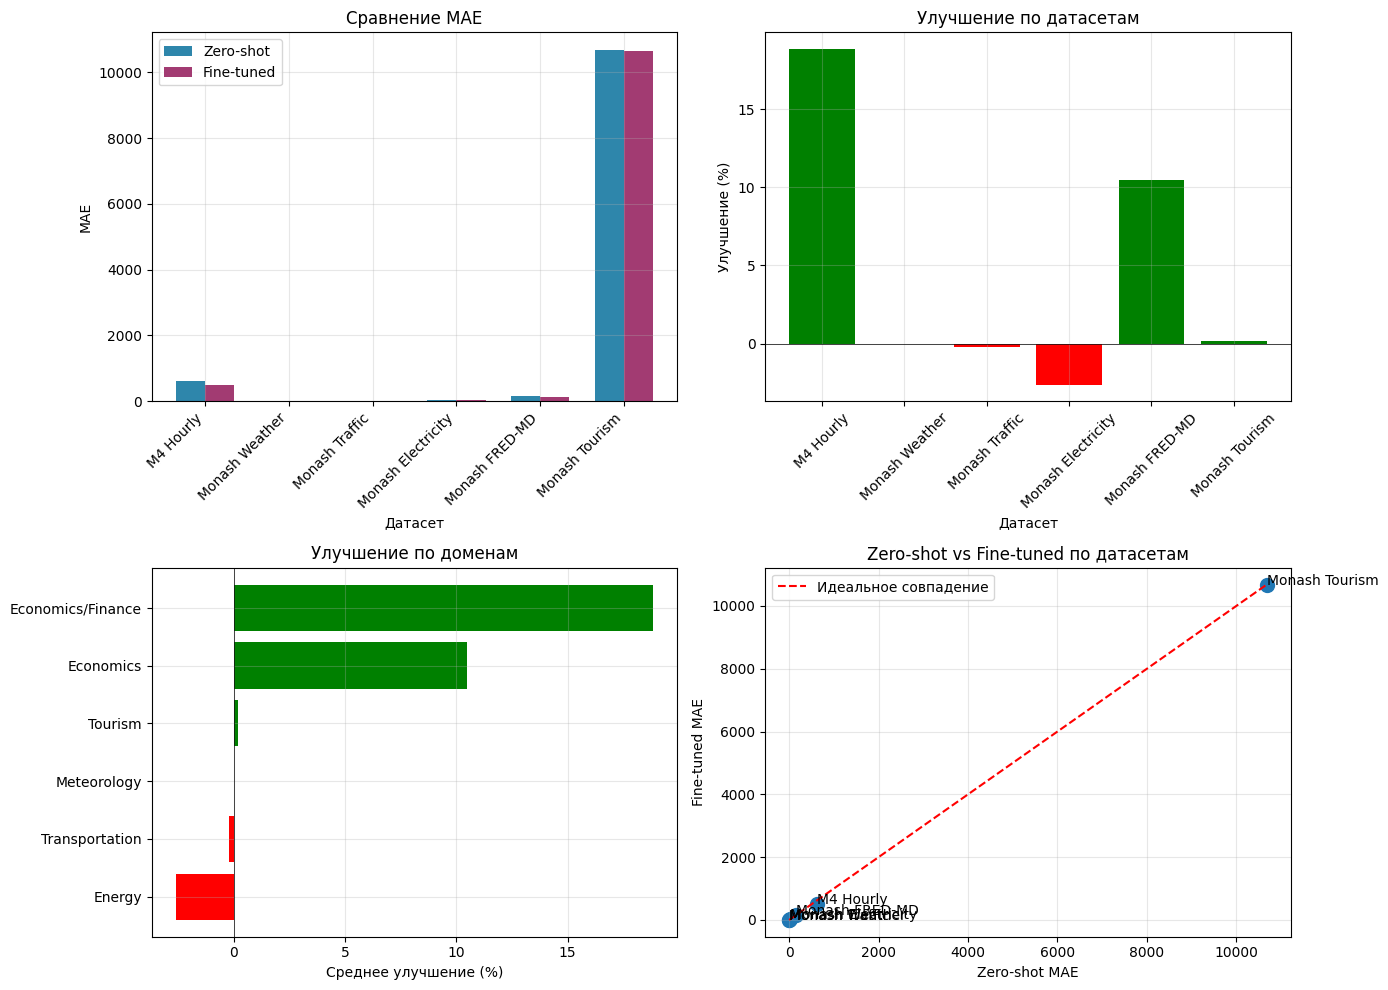

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = results_df['dataset'].values
x = np.arange(len(datasets))
width = 0.35

axes[0, 0].bar(x - width/2, results_df['zero_shot'], width, label='Zero-shot', color='#2E86AB')
axes[0, 0].bar(x + width/2, results_df['fine_tuned'], width, label='Fine-tuned', color='#A23B72')
axes[0, 0].set_xlabel('Датасет')
axes[0, 0].set_ylabel('MAE')
axes[0, 0].set_title('Сравнение MAE')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(datasets, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

colors = ['green' if imp > 0 else 'red' for imp in results_df['improvement']]
axes[0, 1].bar(datasets, results_df['improvement'], color=colors)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].set_xlabel('Датасет')
axes[0, 1].set_ylabel('Улучшение (%)')
axes[0, 1].set_title('Улучшение по датасетам')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

domain_improvement = results_df.groupby('domain')['improvement'].mean().sort_values()
axes[1, 0].barh(domain_improvement.index, domain_improvement.values,
                color=['green' if v > 0 else 'red' for v in domain_improvement.values])
axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].set_xlabel('Среднее улучшение (%)')
axes[1, 0].set_title('Улучшение по доменам')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(results_df['zero_shot'], results_df['fine_tuned'], s=100)
for i, row in results_df.iterrows():
    axes[1, 1].annotate(row['dataset'], (row['zero_shot'], row['fine_tuned']))
max_val = max(results_df['zero_shot'].max(), results_df['fine_tuned'].max())
axes[1, 1].plot([0, max_val], [0, max_val], 'r--', label='Идеальное совпадение')
axes[1, 1].set_xlabel('Zero-shot MAE')
axes[1, 1].set_ylabel('Fine-tuned MAE')
axes[1, 1].set_title('Zero-shot vs Fine-tuned по датасетам')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('chronos_multi_dataset_comparison.png', dpi=150)
plt.show()